# Visualize a Captured Stroke (raw paths)

This notebook loads one JSON stroke sample from `../data/strokes/...` and plots the pen paths. Set `JSON_PATH` to a specific file or let it auto-pick the first found.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt

# Set this to a specific file to visualize, or leave empty to auto-pick
JSON_PATH = ''  # e.g., '../data/strokes/train/א/1712960000000_...json'

base = (Path('..') / 'data' / 'strokes').resolve()
assert base.exists(), f'Missing strokes root: {base}'

def pick_first_sample(root: Path) -> Path | None:
    for split in ['train','val','test']:
        d = root / split
        if not d.exists():
            continue
        # iterate letters
        for L in sorted([p for p in d.iterdir() if p.is_dir()]):
            files = sorted(L.glob('*.json'))
            if files:
                return files[0]
    return None

p = Path(JSON_PATH) if JSON_PATH else pick_first_sample(base)
assert p is not None and p.exists(), 'No stroke JSON found; capture some samples in the app or set JSON_PATH explicitly.'
p


PosixPath('/mnt/c/Users/PerkD/documents/dev/Daber/data/strokes/train/א/1776028309632.json')

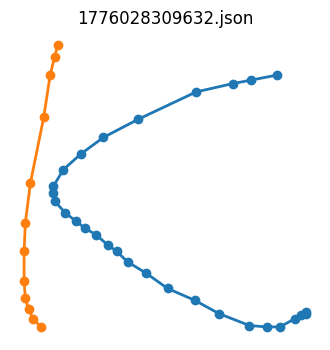

In [2]:
# Load points and re-group by stroke_id
with open(p,'r',encoding='utf-8') as f:
    data = json.load(f)
pts = data['points'] if isinstance(data, dict) else data

# Each row is [x,y,t,stroke_id]; tolerate missing t/sid
xyts = []
for row in pts:
    if len(row) < 2:
        continue
    x = float(row[0]); y = float(row[1])
    t = float(row[2]) if len(row) > 2 else 0.0
    sid = int(row[3]) if len(row) > 3 else 0
    xyts.append((x,y,t,sid))

# Group
strokes = {}
for x,y,t,sid in xyts:
    strokes.setdefault(sid, []).append((x,y))

# Normalize to the box and plot
all_xy = [(x,y) for seg in strokes.values() for (x,y) in seg]
xs = [x for x,_ in all_xy]; ys = [y for _,y in all_xy]
minx,maxx = min(xs), max(xs)
miny,maxy = min(ys), max(ys)
w = max(1e-6, maxx-minx); h = max(1e-6, maxy-miny)

plt.figure(figsize=(4,4))
for sid, seg in sorted(strokes.items()):
    xs = [(x-minx)/w for x,_ in seg]
    ys = [(y-miny)/h for _,y in seg]
    plt.plot(xs, ys, marker='o', linewidth=2)

plt.gca().invert_yaxis()
plt.axis('equal'); plt.axis('off')
plt.title(p.name)
plt.show()
